# TSA Complaints Analysis
Teresa Ferrill  
May 24, 2026

This project will analysis TSA complaint data. There are 4 datasets: one provides information on the complaints, one provides counts by Airport, and another provides counts by category.  The final dataset provides the airport name by code.

-----------------------------------------------------------------------------------------------------------------  
Title  
>Improving Passenger Experience Through Analysis of TSA Complaint Trends  

Audience
>This analysis is designed for TSA operational leadership and airport management stakeholders who are responsible for improving traveler experience and operational efficiency.

Purpose
>The purpose of this analysis is to identify patterns in TSA complaint activity across airports, complaint categories, and geographic regions in order to support targeted operational improvements and resource planning.

Medium
>Python and Jupyter Notebook were used to analyze, clean, and visualize the TSA complaint datasets. The notebook format supports both technical transparency and visual storytelling.

Call to Action
>The analysis recommends that TSA leadership prioritize operational reviews at airports and complaint categories with consistently high complaint volume in order to improve traveler satisfaction and reduce recurring operational issues.

-----------------------------------------------------------------------------------------------------------------
Step 1: Data Preparation 
>Load and explore datasets, confirm datsets loaded correctly  
>>complaints-by-airport.csv  
>>complaints-by-category.csv  
>>complaints-by-subcategory.csv  
>>iata-icao.csv

>Key Cleaning Tasks  
>>Convert Dates  
>>Standardize Airport Codes  
>>Remove Missing Airport Coordinates   

In [1]:
# Step 1A - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global visualization formatting
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

sns.set_palette("Blues")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

colors = ['darkred'] + ['steelblue'] * 9

# Step 1B - Load the four required datasets
airport_df = pd.read_csv("../data/complaints-by-airport.csv")
category_df = pd.read_csv("../data/complaints-by-category.csv")
subcategory_df = pd.read_csv("../data/complaints-by-subcategory.csv")
iata_df = pd.read_csv("../data/iata-icao.csv")

print("Airport complaints:", airport_df.shape)
print("Category complaints:", category_df.shape)
print("Subcategory complaints:", subcategory_df.shape)
print("IATA lookup:", iata_df.shape)

Airport complaints: (41721, 4)
Category complaints: (241588, 7)
Subcategory complaints: (504512, 11)
IATA lookup: (8937, 7)


In [2]:
# Step 1C - Standardize column names
for df in [airport_df, category_df, subcategory_df, iata_df]:
    df.columns = df.columns.str.lower().str.strip()

print("airport_df columns:", airport_df.columns.tolist())
print("category_df columns:", category_df.columns.tolist())
print("subcategory_df columns:", subcategory_df.columns.tolist())
print("iata_df columns:", iata_df.columns.tolist())

airport_df columns: ['pdf_report_date', 'airport', 'year_month', 'count']
category_df columns: ['pdf_report_date', 'airport', 'category', 'year_month', 'count', 'clean_cat', 'clean_cat_status']
subcategory_df columns: ['pdf_report_date', 'airport', 'category', 'subcategory', 'year_month', 'count', 'clean_cat', 'clean_subcat', 'clean_cat_status', 'clean_subcat_status', 'is_category_prefix_removed']
iata_df columns: ['country_code', 'region_name', 'iata', 'icao', 'airport', 'latitude', 'longitude']


In [3]:
# Step 1D - Convert date fields
airport_df["year_month"] = pd.to_datetime(airport_df["year_month"], errors="coerce")
category_df["year_month"] = pd.to_datetime(category_df["year_month"], errors="coerce")
subcategory_df["year_month"] = pd.to_datetime(subcategory_df["year_month"], errors="coerce")

# Step 1E - Standardize airport codes
airport_df["airport"] = airport_df["airport"].astype(str).str.upper().str.strip()
iata_df["iata"] = iata_df["iata"].astype(str).str.upper().str.strip()

# Step 1F - Merge airport complaint data with airport lookup data
merged_df = airport_df.merge(
    iata_df,
    left_on="airport",
    right_on="iata",
    how="left",
    suffixes=("", "_lookup")
)

print(merged_df.head())
print(merged_df.columns.tolist())

  pdf_report_date airport year_month  count country_code   region_name iata  \
0         2019-02     ABE 2015-01-01      0           US  Pennsylvania  ABE   
1         2019-02     ABE 2015-02-01      0           US  Pennsylvania  ABE   
2         2019-02     ABE 2015-03-01      0           US  Pennsylvania  ABE   
3         2019-02     ABE 2015-04-01      0           US  Pennsylvania  ABE   
4         2019-02     ABE 2015-05-01      2           US  Pennsylvania  ABE   

   icao                       airport_lookup  latitude  longitude  
0  KABE  Lehigh Valley International Airport   40.6521   -75.4408  
1  KABE  Lehigh Valley International Airport   40.6521   -75.4408  
2  KABE  Lehigh Valley International Airport   40.6521   -75.4408  
3  KABE  Lehigh Valley International Airport   40.6521   -75.4408  
4  KABE  Lehigh Valley International Airport   40.6521   -75.4408  
['pdf_report_date', 'airport', 'year_month', 'count', 'country_code', 'region_name', 'iata', 'icao', 'airport_lookup'

In [4]:
# Step 1G - Check unmatched airport codes before removing missing locations
missing_airports = merged_df[merged_df["iata"].isna()]

print("Unmatched rows:", len(missing_airports))
print("Unmatched airport codes:")
print(missing_airports["airport"].dropna().unique())

Unmatched rows: 287
Unmatched airport codes:
['CEF' 'JQF' 'JRB' 'NYL' 'UNV']


In [5]:
# Step 1H - Remove records missing airport coordinates
merged_df_clean = merged_df.dropna(subset=["latitude", "longitude"]).copy()

print("Original merged rows:", len(merged_df))
print("Cleaned merged rows:", len(merged_df_clean))
print("Rows removed:", len(merged_df) - len(merged_df_clean))

Original merged rows: 41721
Cleaned merged rows: 41434
Rows removed: 287


In [6]:
# Step 1I - Validate cleaned data
print(merged_df_clean.info())

print("\nMissing values in cleaned merged data:")
print(merged_df_clean.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 41434 entries, 0 to 41720
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pdf_report_date  41434 non-null  object        
 1   airport          41434 non-null  object        
 2   year_month       41434 non-null  datetime64[ns]
 3   count            41434 non-null  int64         
 4   country_code     41434 non-null  object        
 5   region_name      41434 non-null  object        
 6   iata             41434 non-null  object        
 7   icao             41395 non-null  object        
 8   airport_lookup   41434 non-null  object        
 9   latitude         41434 non-null  float64       
 10  longitude        41434 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 3.8+ MB
None

Missing values in cleaned merged data:
pdf_report_date     0
airport             0
year_month          0
count          

Data Cleaning Notes
1. The four required TSA complaint datasets were loaded and inspected.  
2. Column names were standardized to lowercase, date fields were converted to datetime format, and airport codes were standardized to uppercase to support a reliable merge.  
3. The airport complaint dataset was merged with the IATA/ICAO lookup table to add airport name and location information.  
4. Records without latitude and longitude were removed because they could not support spatial analysis.  
5. No complaint counts were altered.  
-------------------------------------------------------------------------------------------

Step 2: Visual 1, TSA Complaints Over Time
>This line chart identifies overall complaint trends across the reporting timeline.

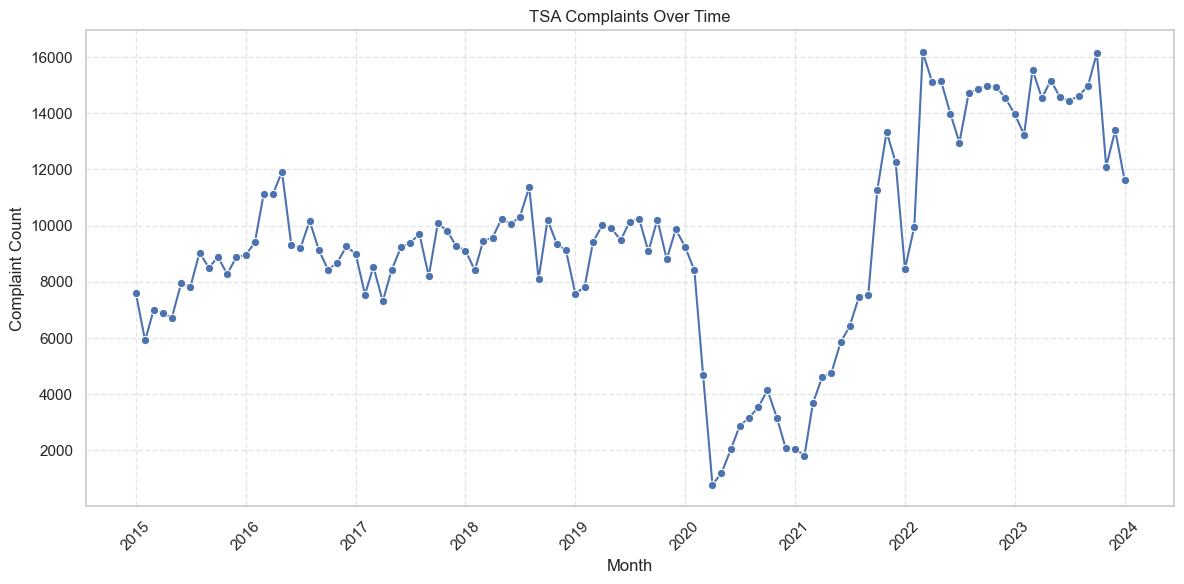

In [7]:
# Visual 1 - TSA complaints over time
monthly_complaints = merged_df_clean.groupby("year_month")["count"].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_complaints, x="year_month", y="count", marker="o")
plt.title("TSA Complaints Over Time")
plt.xlabel("Month")
plt.ylabel("Complaint Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Summary – Visual 1: TSA Complaints Over Time

This visualization shows how TSA complaint activity changes over time across all airports included in the dataset. Complaint levels fluctuate throughout the timeline, which may reflect changes in travel volume, seasonal travel periods, staffing conditions, or operational disruptions. The chart helps identify periods with unusually high complaint activity and provides a high-level view of overall complaint trends that can support operational planning and resource allocation decisions. Complaint activity declined significantly during the COVID-19 pandemic before gradually increasing as travel resumed (TSA, 2024).

-------------------------------------------------------------------------------------------
Step 3: KPI Summary Panel
>This visualization prepares a custom visual of a Key Performance Indicator (KPI) panel, summarizing total complaints, total count of airports, and years analyzed.

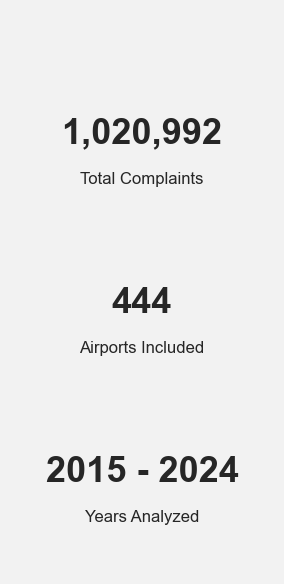

In [8]:
# KPI Summary Panel

# Create year column if it does not already exist
if "year" not in category_df.columns:
    category_df["year"] = pd.to_datetime(category_df["year_month"]).dt.year

# Calculate KPI values
total_complaints = merged_df_clean["count"].sum()
num_airports = merged_df_clean["airport"].nunique()

# Extract minimum and maximum years from category dataset
years_included = (
    int(category_df["year"].min()),
    int(category_df["year"].max())
)

# Create figure for KPI panel
fig, ax = plt.subplots(figsize=(3, 6))
fig.patch.set_facecolor("#f2f2f2")

# Remove axis borders and ticks for cleaner dashboard appearance
ax.set_facecolor("#f2f2f2")
ax.axis("off")

# Display KPI titles and values
kpis = [
    (f"{total_complaints:,}", "Total Complaints"),
    (f"{num_airports}", "Airports Included"),
    (f"{years_included[0]} - {years_included[1]}", "Years Analyzed")
]

# Vertical placement positions for each KPI section
y_positions = [0.78, 0.48, 0.18]


# Loop through KPI values and display them on the panel
for (value, label), y in zip(kpis, y_positions):

    # Display KPI numeric value
    ax.text(
        0.5, y,
        value,
        ha="center",
        va="center",
        fontsize=26,
        fontweight="bold"
    )

    # Display KPI descriptive label below the value
    ax.text(
        0.5, y - 0.08,
        label,
        ha="center",
        va="center",
        fontsize=12
    )

# Add overall panel title
plt.tight_layout()

# Display KPI panel
plt.show()

Executive Summary Metrics

The KPI summary provides a high-level overview of the scope of the analysis before examining the detailed visualizations. The metrics highlight the overall number of TSA complaints included in the dataset, the number of airports represented, and the time period covered by the analysis. Presenting these values first establishes context for the remaining visuals and helps frame the scale of complaint activity across the U.S. airport system. The summary also supports the executive-level focus of the presentation by allowing key information to be understood quickly before reviewing more detailed trends and patterns.

-------------------------------------------------------------------------------------------
Step 4, Visual 2: Top 8 Airports by Complaint Volume
>This horizontal bar chart highlights the airports reporting the highest overall TSA complaint volumes within the dataset.

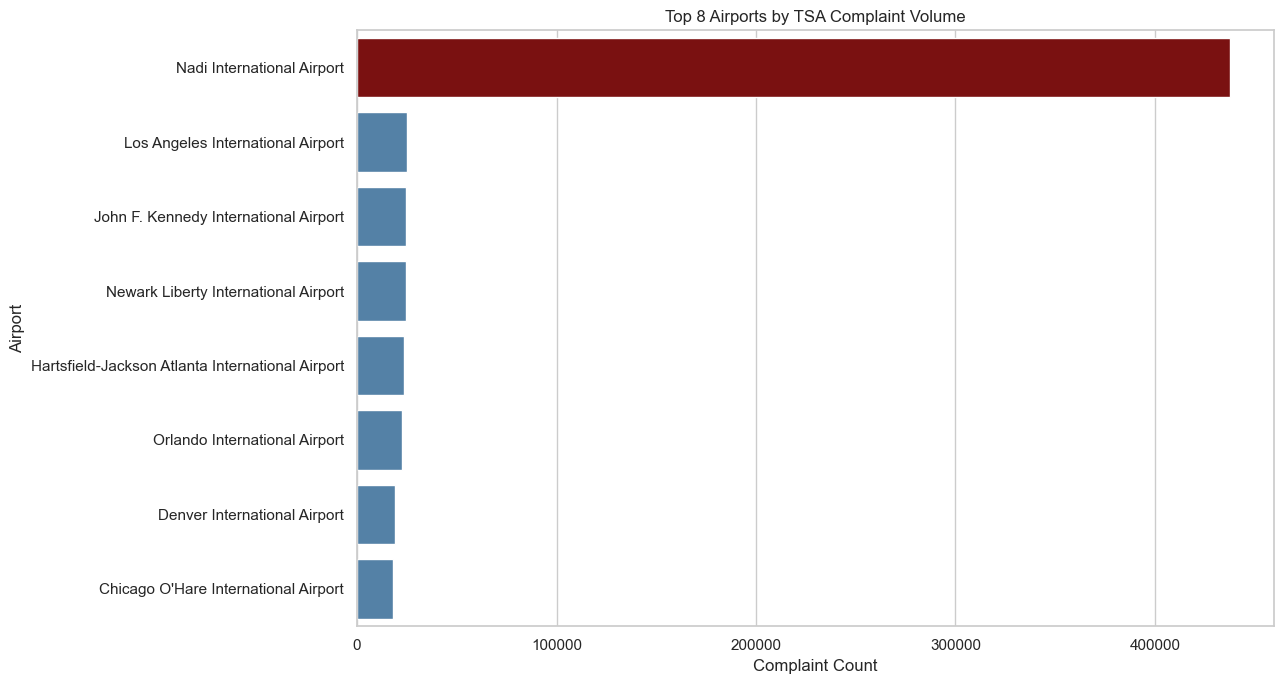

In [9]:
# Visual 2 - Top 8 airports by complaint volume

# Aggregate complaint totals by airport code and airport name
top_airports = (
    merged_df_clean.groupby(["airport", "airport_lookup"])["count"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .reset_index()
)

# Highlight the airport with the highest complaint total
# using a different color for emphasis
colors = ['darkred'] + ['steelblue'] * (len(top_airports) - 1)

# Create horizontal bar chart
plt.figure(figsize=(13, 7))

sns.barplot(
    data=top_airports,
    x="count",
    y="airport_lookup",
    hue="airport_lookup",
    palette=colors,
    legend=False
)

# Add chart title and axis labels
plt.title("Top 8 Airports by TSA Complaint Volume")
plt.xlabel("Complaint Count")
plt.ylabel("Airport")

# Improve layout spacing
plt.tight_layout()

# Display visualization
plt.show()


Summary – Visual 2: Top 8 Airports by Complaint Volume

This visualization identifies the airports with the highest overall TSA complaint volume in the dataset. The results show that complaint activity is concentrated among a relatively small number of airports, suggesting that larger or higher-traffic locations may experience more operational challenges and customer service concerns. Identifying these airports can help TSA leadership prioritize operational reviews, staffing adjustments, and targeted improvement initiatives where complaint activity is consistently highest.

-------------------------------------------------------------------------------------------
Step 5: Visual 3, Top TSA Complaint Categories  
>This bar chart visualization highlights the complaint categories with the highest overall complaint volume in the dataset.

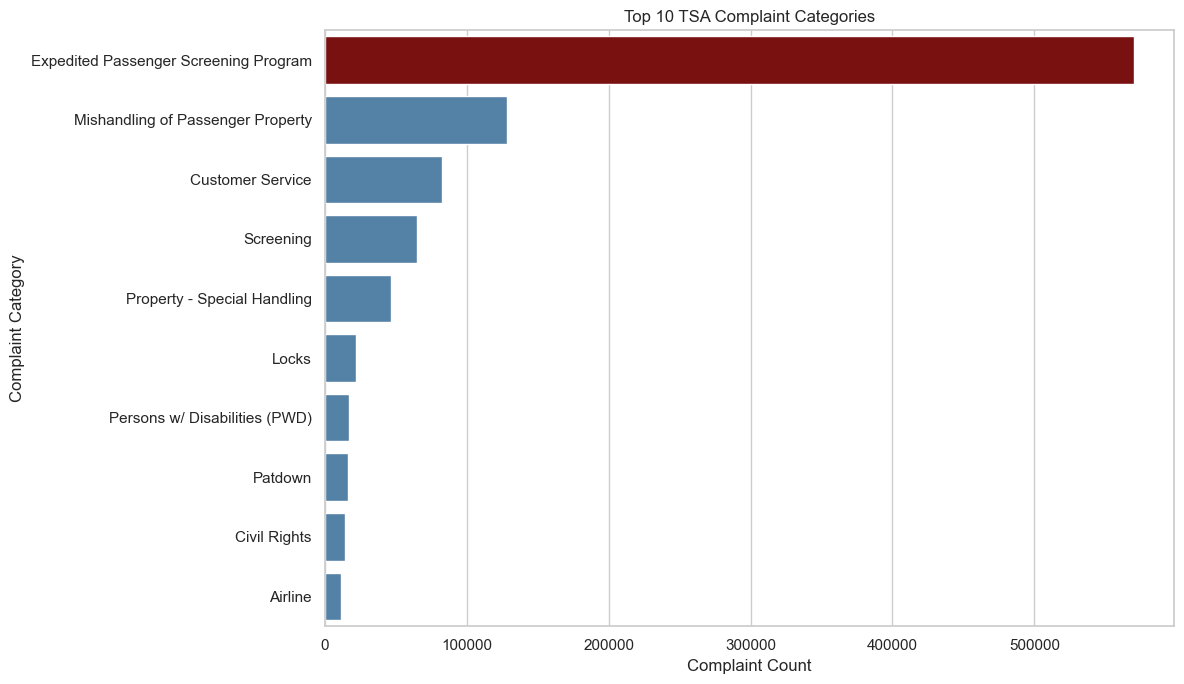

In [10]:
# Visual 3 - Top TSA complaint categories

# Aggregate total complaint counts by category
# and select the top 10 highest categories
category_totals = (
    category_df.groupby("category")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Highlight the highest complaint category
# using a different color for emphasis
colors = ['darkred'] + ['steelblue'] * (len(category_totals) - 1)

# Create horizontal bar chart
plt.figure(figsize=(12, 7))

sns.barplot(
    data=category_totals,
    x="count",
    y="category",
    hue="category",
    palette=colors,
    legend=False
)

# Add chart title and axis labels
plt.title("Top 10 TSA Complaint Categories")
plt.xlabel("Complaint Count")
plt.ylabel("Complaint Category")

# Improve spacing and layout appearance
plt.tight_layout()

# Display visualization
plt.show()

Summary – Visual 3: Top TSA Complaint Categories

This visualization highlights the complaint categories with the highest overall complaint volume. A small number of categories account for a large share of total complaints, indicating that certain operational or customer service issues occur more consistently across airports. Focusing improvement efforts on these high-volume categories may help TSA leadership reduce complaint frequency and improve traveler satisfaction more effectively than broad, unfocused initiatives.

-------------------------------------------------------------------------------------------
Step 6: Visual 4, TSA Complaint Categories Over Time  
>This heat map visualizes changes in complaint activity across categories and time periods.

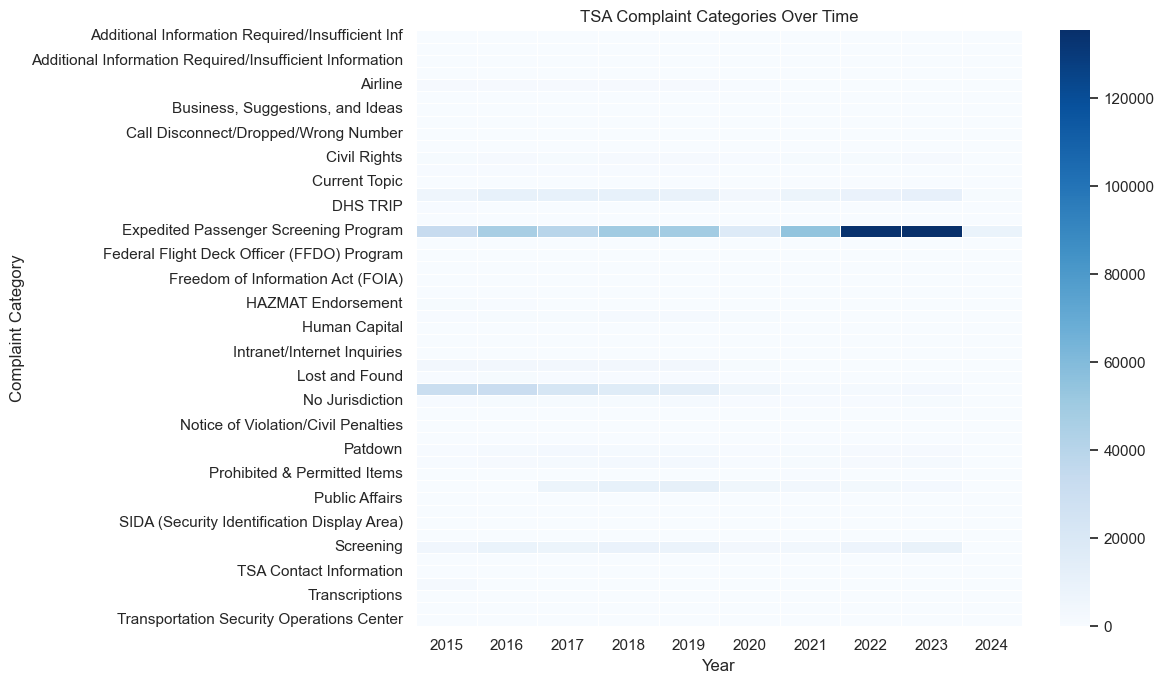

In [11]:
# Visual 4 - TSA Complaint Categories Over Time

# Create year column
category_df["year"] = category_df["year_month"].dt.year

# Build pivot table
heatmap_data = category_df.pivot_table(
    index="category",
    columns="year",
    values="count",
    aggfunc="sum",
    fill_value=0
)

# Create heat map
plt.figure(figsize=(12, 7))

sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5
)

# Add chart title and axis labels
plt.title("TSA Complaint Categories Over Time")
plt.xlabel("Year")
plt.ylabel("Complaint Category")

# Improve spacing and layout appearance
plt.tight_layout()

# Display visualization
plt.show()

Summary – Visual 4: Heat Map of Complaint Categories by Year

This heat map highlights how TSA complaint categories change over time and helps identify periods where specific complaint types become more frequent. Darker areas indicate higher complaint activity, making it easier to detect recurring operational trends across multiple years. The visualization supports long-term trend analysis by allowing TSA leadership to quickly identify categories that may require additional operational review or policy improvements.  

-------------------------------------------------------------------------------------------
Step 7: Visual 5, Distribution of Complaint Counts by Year  
>This box plot compares the distribution of TSA complaint counts across reporting years.

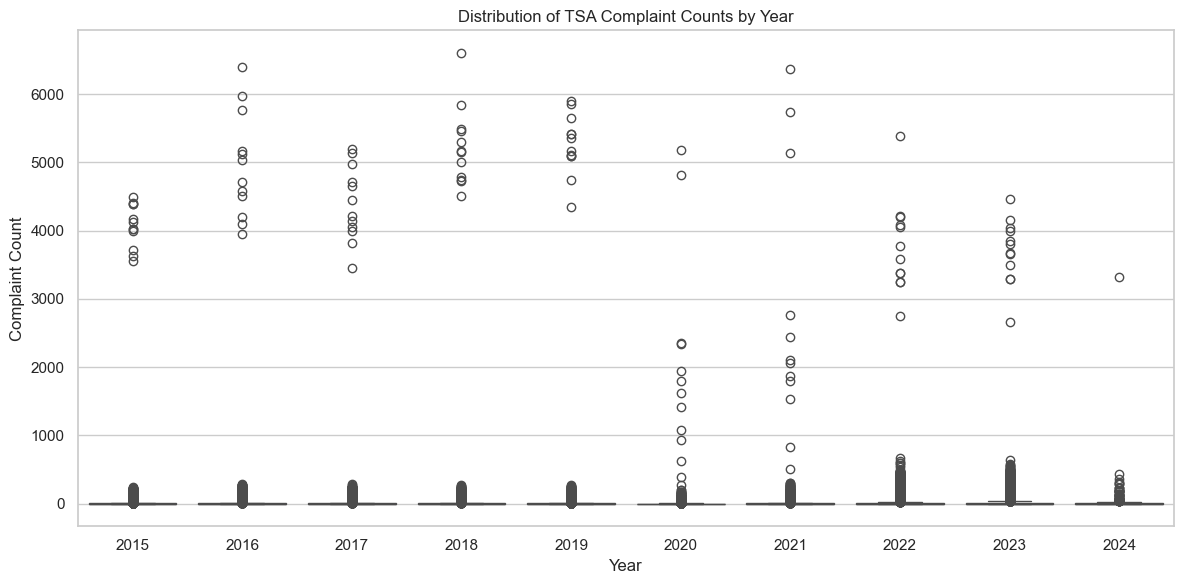

In [12]:
# Visual 6 - Distribution of Complaint Counts by Year

# Create year column for box plot grouping
merged_df_clean["year"] = merged_df_clean["year_month"].dt.year

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=merged_df_clean,
    x="year",
    y="count"
)

# Add chart title and axis labels
plt.title("Distribution of TSA Complaint Counts by Year")
plt.xlabel("Year")
plt.ylabel("Complaint Count")

# Improve spacing and layout appearance
plt.tight_layout()

# Display visualization
plt.show()

Summary – Visual 5: Distribution of TSA Complaint Counts by Year

This box plot compares the distribution of TSA complaint counts across reporting years. The chart shows how complaint activity varies within each year and helps identify years with wider variation or unusually high complaint counts. This supports operational review by showing whether complaint patterns remain consistent over time or whether certain years experienced more noticeable spikes.

-------------------------------------------------------------------------------------------
Step 8: Visual 6, Geographic Distribution of TSA Complaints Across U.S. Airports 
>This spatial visualization displays the geographic distribution of TSA complaint activity across US airports.

In [13]:
# Visual 6 - Spatial visual: Geographic Distribution of TSA Complaints Across U.S. Airports
import plotly.express as px

# Aggregate complaint totals by airport location and airport name
airport_location_totals = (
    merged_df_clean.groupby(
        ["airport", "airport_lookup", "latitude", "longitude"]
    )["count"]
    .sum()
    .reset_index()
)

# Create geographic scatter map
fig = px.scatter_geo(
    airport_location_totals,
    lat="latitude",
    lon="longitude",
    size="count",
    color="count",
    hover_name="airport_lookup",
    hover_data={
        "airport": True,
        "count": True,
        "latitude": False,
        "longitude": False
    },
    scope="usa",
    projection="albers usa",
    title="Geographic Distribution of TSA Complaints Across U.S. Airports",
    size_max=35
)

fig.update_layout(
    height=700,
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig.show()

# Display top airports by complaint volume
top_spatial_airports = (
    airport_location_totals
    .sort_values(by="count", ascending=False)
    .head(10)
)

display(
    top_spatial_airports[
        ["airport_lookup", "airport", "count"]
    ].rename(
        columns={
            "airport_lookup": "Airport Name",
            "airport": "Airport Code",
            "count": "Complaint Count"
        }
    )
)

,Airport Name,Airport Code,Complaint Count
295,Nadi International Airport,NAN,437786
231,Los Angeles International Airport,LAX,24794
219,John F. Kennedy International Airport,JFK,24677
137,Newark Liberty International Airport,EWR,24405
26,Hartsfield-Jackson Atlanta International Airport,ATL,23591
260,Orlando International Airport,MCO,22308
111,Denver International Airport,DEN,19015
306,Chicago O'Hare International Airport,ORD,18256
112,Dallas/Fort Worth International Airport,DFW,15954
229,Harry Reid International Airport,LAS,15937


Summary – Visual 6: Spatial View of TSA Complaint Volume by Airport

This spatial visualization displays the geographic distribution of TSA complaint volume across airports included in the dataset. Larger markers represent airports with higher complaint counts, making it easier to identify regions and airport locations where complaint activity is more concentrated. The map provides a broader operational perspective by combining complaint data with geographic location information, which can help support regional planning, resource allocation, and targeted operational improvement efforts.

-------------------------------------------------------------------------------------------

## Overall Findings and Recommendations

The TSA complaint data shows that complaint activity is concentrated around a relatively small number of airports and operational categories. Complaint levels also fluctuate over time, suggesting that seasonal travel patterns and operational conditions may influence customer experiences. Spatial analysis further demonstrates that complaint activity is not evenly distributed geographically.

The results support the recommendation that TSA leadership prioritize operational reviews at high-volume airports and focus improvement initiatives on the most common complaint categories. Targeted improvements in staffing, communication, and passenger screening consistency may help reduce complaint frequency and improve traveler satisfaction.

## Ethical Considerations

The TSA complaint datasets were obtained from publicly available sources and were used without altering complaint totals or categories. Cleaning activities were limited to formatting adjustments, date conversion, airport code standardization, and removal of records missing geographic coordinates required for mapping analysis.

One limitation is that complaint counts alone do not provide operational context or indicate whether complaints were validated. Higher complaint counts may also reflect larger airport traffic volume rather than lower service quality. To reduce the risk of misleading conclusions, the analysis focuses on observable complaint patterns rather than assigning fault or causation.  Records missing airport coordinates were removed only from the spatial analysis because those records could not be accurately mapped.  

Visualizations should present data clearly without misleading the audience through unnecessary distortion or omission (Cairo, 2016).

## Design Choices

The visualizations were designed to support readability and quick interpretation for TSA operational leadership and airport stakeholders. Consistent color themes and chart formatting were used throughout the notebook to improve visual continuity. Horizontal bar charts were selected where category labels were lengthy to improve readability, while line charts and heat maps were used to highlight trends over time. Spacing, alignment, and figure sizing were adjusted to reduce clutter and improve presentation clarity.

Gestalt principles were considered by grouping related elements together, maintaining consistent alignment, and using color contrast to emphasize higher complaint activity. Simpler chart styles were selected to keep attention focused on the data rather than decorative formatting.  

Consistent color and spacing choices were used to support readability and reduce cognitive load in accordance with data storytelling best practices (Knaflic, 2015).

## Data Sources

The TSA complaint datasets were obtained from the publicly available GitHub TSA complaint counts repository provided in the course assignment instructions. Airport location and lookup information was obtained from the IATA/ICAO airport reference dataset supplied with the assignment materials.

## Final Notes

All analysis was completed using Python within a Jupyter Notebook environment. Visualizations were created using Matplotlib, Seaborn, and geographic plotting libraries. The notebook provides a reproducible workflow for loading, cleaning, analyzing, and visualizing TSA complaint data. The visualizations were designed to emphasize clarity, readability, and accurate communication of the data (Knaflic, 2015).

# References

Cairo, A. (2016). *The truthful art: Data, charts, and maps for communication*. New Riders.

Knaflic, C. N. (2015). *Storytelling with data: A data visualization guide for business professionals*. Wiley.

Transportation Security Administration. (2024). TSA complaint datasets. Retrieved from https://github.com/tsa

International Air Transport Association (IATA). (2024). Airport codes and location data. Retrieved from https://www.iata.org/